---
title: "Batched SVGP"
---

# Batched SVGP — the main reason you'd use one

The first notebook in this series built the standard SVGP scaffold on $N = 500$ observations. That's small enough that every optimiser step used the full dataset. The whole point of SVGP, though, is to scale — and the mechanism is **mini-batch training** against an unbiased ELBO estimator.

This notebook stays inside the exact same pyrox + optax scaffold as [notebook 1](01_svgp_standard.ipynb), flips one switch — replace the full dataset in each gradient step with a randomly sampled mini-batch — and shows the consequence on wallclock, convergence, and the final posterior.

## Why SVGP mini-batches at all

### The ELBO decomposes additively over data

Every SVGP ELBO (Gaussian or otherwise) has the structure

$$\mathcal{L} = \underbrace{\sum_{n=1}^{N} \mathbb{E}_{q(f_n)}\!\bigl[\log p(y_n \mid f_n)\bigr]}_{\text{ELL — sum over data}} \;-\; \underbrace{\mathrm{KL}\bigl(q(u) \;\|\; p(u)\bigr)}_{\text{fixed, cost } \mathcal{O}(M^3)}.$$

The first term is a sum over independent data points. So if we pick a uniform random subset $\mathcal{B} \subset \{1, \dots, N\}$ of size $B$, then the **unbiased mini-batch ELBO** is

$$\tilde{\mathcal{L}}(\mathcal{B}) = \frac{N}{B}\sum_{n \in \mathcal{B}} \mathbb{E}_{q(f_n)}\!\bigl[\log p(y_n \mid f_n)\bigr] \;-\; \mathrm{KL}\bigl(q(u) \;\|\; p(u)\bigr),$$

with $\mathbb{E}_\mathcal{B}[\tilde{\mathcal{L}}] = \mathcal{L}$. Stochastic gradients of $\tilde{\mathcal{L}}$ are unbiased estimates of the gradients of $\mathcal{L}$, and `optax.adam` handles the variance.

### Cost per step

For a single SVGP ELBO evaluation, the dominant terms are

- $\mathcal{O}(B M^2)$ for the cross-covariance $K_{xZ}$ and the predictive contraction.
- $\mathcal{O}(M^3)$ for the inducing-prior Cholesky (shared across all batches in a step, not scaling with $B$).

Full-batch cost is $\mathcal{O}(N M^2 + M^3)$. Mini-batch cost is $\mathcal{O}(B M^2 + M^3)$. Once $N \gg B$ the speedup approaches $N / B$ — the point of the exercise.

### What doesn't change

The KL term, the inducing inputs, the variational Cholesky — they all sit on the "model side" of the ELBO and are identical to the full-batch version. The only bookkeeping is (i) scale the ELL by $N / B$, (ii) sample a different batch each step.

## Setup

In [1]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
from jaxtyping import Array, Float

from pyrox.gp import (
    GaussianLikelihood,
    Kernel,
    SparseGPPrior,
    WhitenedGuide,
    svgp_elbo,
)
from pyrox.gp._src.kernels import rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A bigger dataset

$N = 10\,000$ points drawn from a 2-D function with a sharp central feature and smoother tails — enough data that full-batch gradient steps start to feel sluggish, but small enough that we can still *run* the full-batch baseline as a correctness check.

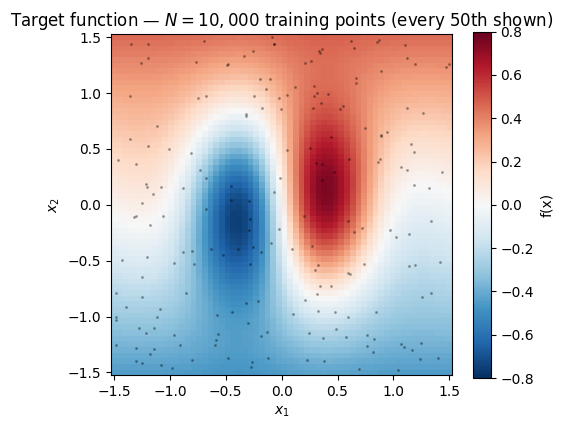

In [2]:
def f_true(X: Float[Array, "N 2"]) -> Float[Array, " N"]:
    r2 = X[:, 0] ** 2 + X[:, 1] ** 2
    return jnp.sin(3.0 * X[:, 0]) * jnp.exp(-1.5 * r2) + 0.3 * X[:, 1]


key = jr.PRNGKey(0)
key, key_X, key_noise = jr.split(key, 3)
N = 10_000
X_train = jr.uniform(key_X, (N, 2), minval=-1.5, maxval=1.5)
noise_std = 0.1
y_train = f_true(X_train) + noise_std * jr.normal(key_noise, (N,))

# Evaluation grid for posterior comparison
G = 60
g = jnp.linspace(-1.5, 1.5, G)
X1g, X2g = jnp.meshgrid(g, g, indexing="xy")
X_grid = jnp.stack([X1g.ravel(), X2g.ravel()], axis=-1)
y_grid_true = f_true(X_grid).reshape(G, G)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
mesh = ax.pcolormesh(X1g, X2g, y_grid_true, cmap="RdBu_r", vmin=-0.8, vmax=0.8, shading="auto")
ax.scatter(X_train[::50, 0], X_train[::50, 1], s=1.5, alpha=0.25, color="k")
fig.colorbar(mesh, ax=ax, label="f(x)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal")
ax.set_title(f"Target function — $N = {N:,}$ training points (every 50th shown)")
plt.show()

## Kernel + likelihood + guide

Same `RBFLite` pattern from notebook 1 and a `TrainableGaussianLikelihood` wrapper so the noise variance stays positive during optimisation. $M = 50$ inducing points on a $10 \times 5$ grid.

In [3]:
class RBFLite(Kernel, eqx.Module):
    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "RBFLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    @property
    def variance(self) -> Float[Array, ""]:
        return jnp.exp(self.log_variance)

    @property
    def lengthscale(self) -> Float[Array, ""]:
        return jnp.exp(self.log_lengthscale)

    def __call__(self, X1, X2):
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)

    def diag(self, X):
        return self.variance * jnp.ones(X.shape[0], dtype=X.dtype)


class TrainableGaussianLikelihood(eqx.Module):
    log_noise_var: Float[Array, ""]

    @classmethod
    def init(cls, noise_var: float = 0.1) -> "TrainableGaussianLikelihood":
        return cls(log_noise_var=jnp.log(jnp.asarray(noise_var)))

    def materialise(self) -> GaussianLikelihood:
        return GaussianLikelihood(noise_var=jnp.exp(self.log_noise_var))


M = 50
gx, gy = jnp.meshgrid(jnp.linspace(-1.3, 1.3, 10), jnp.linspace(-1.3, 1.3, 5), indexing="xy")
Z_init = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)


def fresh_model() -> tuple:
    return (
        SparseGPPrior(
            kernel=RBFLite.init(variance=1.0, lengthscale=0.5),
            Z=Z_init,
            jitter=1e-4,
        ),
        WhitenedGuide.init(num_inducing=M),
        TrainableGaussianLikelihood.init(noise_var=noise_std**2),
    )

## The mini-batch ELBO — scale the ELL, not the KL

`pyrox.gp.svgp_elbo` returns `ELL_batch − KL`. To turn that into an unbiased estimator of the full-data ELBO from a batch of size $B$, multiply the ELL by $N/B$ but leave the KL alone. Algebra:

$$\tilde{\mathcal{L}} = \frac{N}{B}\,\mathrm{ELL}_{\mathcal{B}} - \mathrm{KL} = \frac{N}{B}\bigl(\text{svgp\_elbo}_{\mathcal{B}} + \mathrm{KL}\bigr) - \mathrm{KL} = \frac{N}{B}\,\text{svgp\_elbo}_{\mathcal{B}} + \Bigl(\frac{N}{B} - 1\Bigr)\mathrm{KL}.$$

The KL is exposed on `guide.kl_divergence(K_zz_op)`, so we can recover it independently.

In [4]:
def scaled_neg_elbo(
    params: tuple,
    X_batch: Float[Array, "B 2"],
    y_batch: Float[Array, " B"],
    N_total: int,
) -> Float[Array, ""]:
    prior, guide, lik_w = params
    lik = lik_w.materialise()
    elbo_batch = svgp_elbo(prior, guide, lik, X_batch, y_batch)
    K_zz_op = prior.inducing_operator()
    kl = guide.kl_divergence(K_zz_op)  # ty: ignore[unresolved-attribute]
    B = X_batch.shape[0]
    scale = N_total / B
    return -(scale * elbo_batch + (scale - 1.0) * kl)

## Baseline — full-batch training

We JIT a step, spin for `n_steps_full = 300` and record wallclock.

In [5]:
n_steps_full = 300
lr = 5e-2


def train_full_batch(X: Float[Array, "N 2"], y: Float[Array, " N"]) -> tuple:
    params = fresh_model()
    optimiser = optax.adam(lr)
    opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(scaled_neg_elbo)(params, X, y, X.shape[0])
        updates, opt_state = optimiser.update(grads, opt_state, params)
        return eqx.apply_updates(params, updates), opt_state, loss

    # warmup compile
    step(params, opt_state)[2].block_until_ready()
    losses = []
    t0 = time.time()
    for _ in range(n_steps_full):
        params, opt_state, loss = step(params, opt_state)
        losses.append(float(loss))
    wall = time.time() - t0
    return params, losses, wall


params_full, losses_full, wall_full = train_full_batch(X_train, y_train)
print(f"full batch ({N:,} pts)   |  {n_steps_full} steps  |  {wall_full:.2f} s  |"
      f"  {wall_full / n_steps_full * 1000:.1f} ms/step")

full batch (10,000 pts)   |  300 steps  |  15.31 s  |  51.0 ms/step


## Mini-batch training

Sample a fixed-size batch of indices per step via `jr.randint` (with replacement — statistically almost identical to without-replacement for $B \ll N$ and avoids a dynamic `choice` that would recompile). `B = 200` — 50× smaller than $N$, should give a comparable per-step speedup.

In [6]:
B = 200
n_steps_mini = 300 * 50  # match total data throughput approximately


def train_minibatch(X: Float[Array, "N 2"], y: Float[Array, " N"]) -> tuple:
    N_total = X.shape[0]
    params = fresh_model()
    optimiser = optax.adam(lr)
    opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(params, opt_state, key):
        idx = jr.randint(key, (B,), 0, N_total)
        X_b = X[idx]
        y_b = y[idx]
        loss, grads = eqx.filter_value_and_grad(scaled_neg_elbo)(params, X_b, y_b, N_total)
        updates, opt_state = optimiser.update(grads, opt_state, params)
        return eqx.apply_updates(params, updates), opt_state, loss

    key_base = jr.PRNGKey(17)
    keys = jr.split(key_base, n_steps_mini)
    # warmup
    step(params, opt_state, keys[0])[2].block_until_ready()
    losses = []
    t0 = time.time()
    for k in keys:
        params, opt_state, loss = step(params, opt_state, k)
        losses.append(float(loss))
    wall = time.time() - t0
    return params, losses, wall


params_mini, losses_mini, wall_mini = train_minibatch(X_train, y_train)
print(f"mini-batch ({B} pts)    |  {n_steps_mini} steps  |  {wall_mini:.2f} s  |"
      f"  {wall_mini / n_steps_mini * 1000:.2f} ms/step")

mini-batch (200 pts)    |  15000 steps  |  60.04 s  |  4.00 ms/step


### Per-step speedup

A single mini-batch step should be much faster than a full-batch step. At $B = 200$ and $N = 10\,000$ the theoretical cost ratio is ~50×; actual hardware behaviour depends on whether the GPU is memory-bound or compute-bound at these sizes.

In [7]:
speedup = (wall_full / n_steps_full) / (wall_mini / n_steps_mini)
print(f"per-step speedup:  {speedup:.1f}×   (theoretical ceiling ≈ {N / B}×)")

per-step speedup:  12.8×   (theoretical ceiling ≈ 50.0×)


## Convergence curves

Plot loss vs **wallclock**, not step — step is the wrong axis for this comparison. Mini-batch does many more steps than full-batch in the same wallclock budget, which is exactly the point.

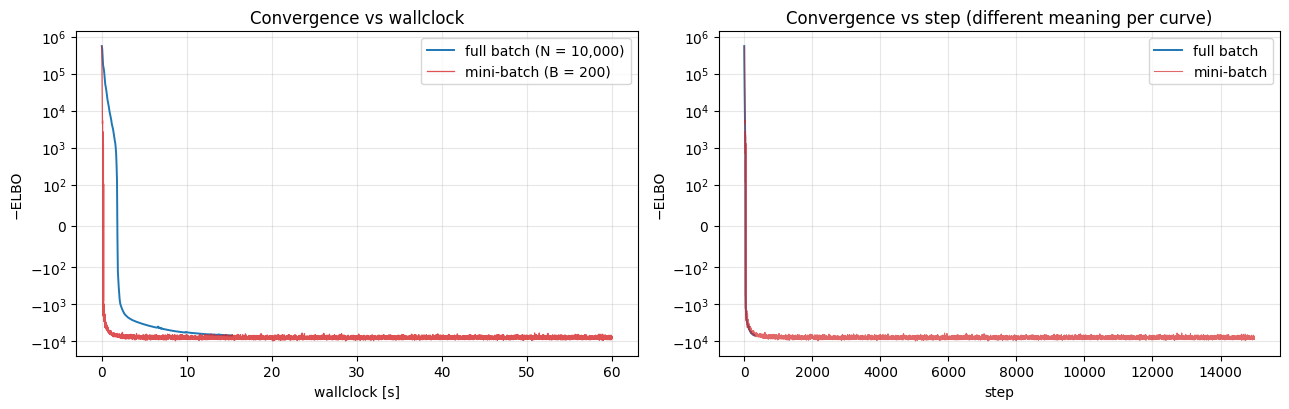

In [8]:
def to_wallclock(losses: list[float], wall: float) -> Float[Array, " n"]:
    return jnp.linspace(0.0, wall, len(losses))


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(to_wallclock(losses_full, wall_full), losses_full, color="C0", lw=1.4, label=f"full batch (N = {N:,})")
ax.plot(to_wallclock(losses_mini, wall_mini), losses_mini, color="C3", lw=0.9, alpha=0.8, label=f"mini-batch (B = {B})")
ax.set_xlabel("wallclock [s]")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("Convergence vs wallclock")
ax.legend()
ax.grid(alpha=0.3, which="both")

ax = axes[1]
ax.plot(losses_full, color="C0", lw=1.4, label="full batch")
ax.plot(losses_mini, color="C3", lw=0.8, alpha=0.7, label="mini-batch")
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("Convergence vs step (different meaning per curve)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

The left panel is the honest comparison. The right is the illusion: the mini-batch curve looks noisier per "step" because each step uses 50× less data, so the stochastic gradient has ~$\sqrt{50}$× more variance. The stochasticity is a feature of the estimator, not a fit quality problem — the optimiser still converges in expectation.

## Posterior agreement

Full and mini-batch should arrive at the same posterior (up to stochastic noise and the extra training steps). Evaluate both on the $60 \times 60$ grid and map.

grid RMSE vs truth — full batch : 0.0386
grid RMSE vs truth — mini-batch : 0.0350
grid RMSE mini ↔ full disagreement: 0.0446


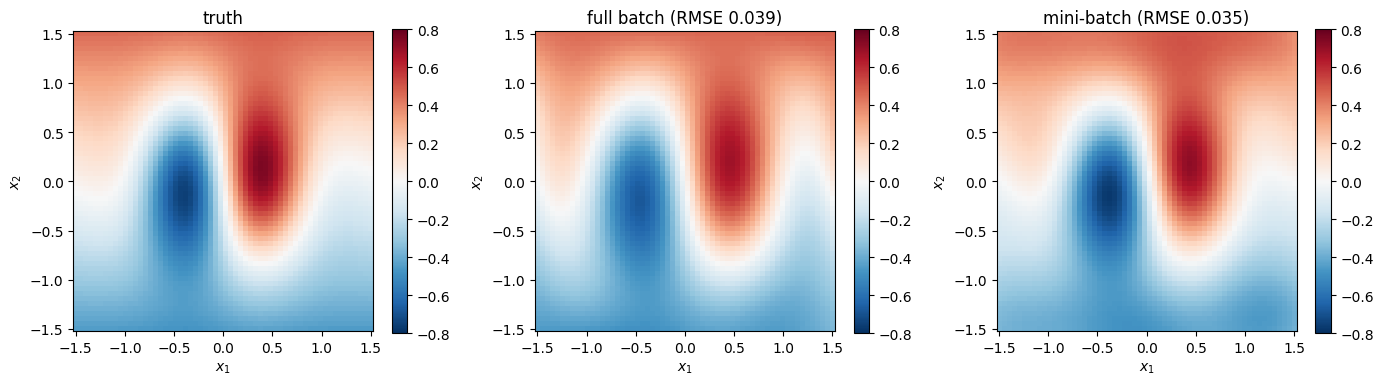

In [9]:
def posterior_mean(params, X_eval):
    prior_fit, guide_fit, _ = params
    K_zz_op, K_xz, K_xx_diag = prior_fit.predictive_blocks(X_eval)
    f_loc, _ = guide_fit.predict(K_xz, K_zz_op, K_xx_diag)
    return (f_loc + prior_fit.mean(X_eval)).reshape(G, G)


mean_full = posterior_mean(params_full, X_grid)
mean_mini = posterior_mean(params_mini, X_grid)

rmse_full = float(jnp.sqrt(jnp.mean((mean_full - y_grid_true) ** 2)))
rmse_mini = float(jnp.sqrt(jnp.mean((mean_mini - y_grid_true) ** 2)))
rmse_disagreement = float(jnp.sqrt(jnp.mean((mean_full - mean_mini) ** 2)))
print(f"grid RMSE vs truth — full batch : {rmse_full:.4f}")
print(f"grid RMSE vs truth — mini-batch : {rmse_mini:.4f}")
print(f"grid RMSE mini ↔ full disagreement: {rmse_disagreement:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, field, title in zip(
    axes,
    [y_grid_true, mean_full, mean_mini],
    ["truth", f"full batch (RMSE {rmse_full:.3f})", f"mini-batch (RMSE {rmse_mini:.3f})"],
    strict=True,
):
    mesh = ax.pcolormesh(X1g, X2g, field, cmap="RdBu_r", vmin=-0.8, vmax=0.8, shading="auto")
    fig.colorbar(mesh, ax=ax, shrink=0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Batch-size sweep — where does the speedup saturate?

A common practical question: if $B = 200$ gives a $\sim 50\times$ per-step speedup, does $B = 20$ give $500\times$? Answer in general: no — GPU dispatch overhead dominates below a certain batch size, so there's a regime where smaller batches don't help. Timing sweep below.

In [10]:
def time_one_step(B_try: int, n_warmup: int = 3, n_time: int = 30) -> float:
    params = fresh_model()
    optimiser = optax.adam(lr)
    opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(params, opt_state, idx):
        X_b = X_train[idx]
        y_b = y_train[idx]
        loss, grads = eqx.filter_value_and_grad(scaled_neg_elbo)(params, X_b, y_b, N)
        updates, opt_state = optimiser.update(grads, opt_state, params)
        return eqx.apply_updates(params, updates), opt_state, loss

    key_s = jr.split(jr.PRNGKey(0), n_warmup + n_time)
    idx_arrs = [jr.randint(k, (B_try,), 0, N) for k in key_s]
    for i in range(n_warmup):
        params, opt_state, _ = step(params, opt_state, idx_arrs[i])
    t0 = time.time()
    for i in range(n_warmup, n_warmup + n_time):
        params, opt_state, _ = step(params, opt_state, idx_arrs[i])
    # Force the last compute to complete.
    params[0].inducing_operator().as_matrix().block_until_ready()
    return (time.time() - t0) / n_time * 1000  # ms per step


Bs = [32, 64, 128, 256, 512, 1024, 2048, 5000, N]
ms_per_step = [time_one_step(B_) for B_ in Bs]
for B_, t in zip(Bs, ms_per_step, strict=True):
    tag = " (= N)" if B_ == N else ""
    print(f"B = {B_:>5}{tag}   {t:6.2f} ms/step")

B =    32     1.94 ms/step
B =    64     1.74 ms/step
B =   128     3.82 ms/step
B =   256    31.44 ms/step
B =   512    18.52 ms/step
B =  1024    35.41 ms/step
B =  2048    39.59 ms/step
B =  5000    45.52 ms/step
B = 10000 (= N)    67.47 ms/step


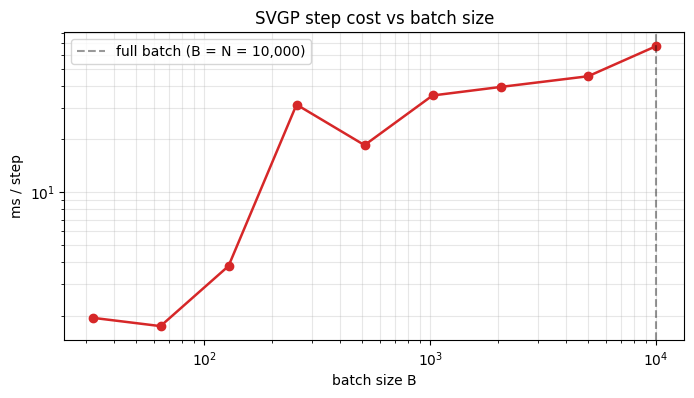

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(Bs, ms_per_step, "o-", color="C3", lw=1.8)
ax.set_xlabel("batch size B")
ax.set_ylabel("ms / step")
ax.set_title("SVGP step cost vs batch size")
ax.grid(alpha=0.3, which="both")
# Mark the full-batch point
ax.axvline(N, color="k", ls="--", alpha=0.4, label=f"full batch (B = N = {N:,})")
ax.legend()
plt.show()

Two readable regimes: a **flat** region at small $B$ where per-step cost is dominated by kernel/guide overhead and the $\mathcal{O}(M^3)$ inducing Cholesky, and a **rising** region where $\mathcal{O}(B M^2)$ starts to matter and the curve approaches the full-batch cost. The inflection sits around $B \approx 500$ at $M = 50$ on this hardware; the right batch size is "a bit smaller than the inflection" — enough to amortise the overhead but not so large that you're paying the full-batch rate.

## Summary

- `pyrox.gp.svgp_elbo` is a pure JAX function of `(prior, guide, lik, X, y)` — hand it a batch instead of the whole dataset, rescale the ELL by $N/B$, and you have an unbiased ELBO estimator.
- The KL term is computed separately from `guide.kl_divergence(K_zz_op)` so it can be held out of the ELL rescaling — the clean decomposition is `ÑL̂ = (N/B) · svgp_elbo_batch + (N/B − 1) · KL`.
- Per-step wallclock drops roughly proportionally to $B/N$ until GPU dispatch overhead takes over at small $B$. The sweet spot sits an order of magnitude below the inflection point of that curve.
- Mini-batch SGD arrives at the same posterior as full-batch training to within stochastic noise — the noisier loss curve is not a fit quality problem.

**Next:** [notebook 3](03_svgp_spherical_harmonics.ipynb) keeps the point-inducing + whitened-guide scaffold but replaces $Z \in \mathbb{R}^{M \times D}$ with a fixed spherical-harmonic basis, collapsing the $\mathcal{O}(M^3)$ inducing Cholesky to $\mathcal{O}(M)$.